# Homework Assignment Solution: Classifier Evaluation

BINF 6210/8210: Machine Learning for Bioinformatics
___

This notebook provides one defensible solution. Alternative scientifically justified choices may receive full credit.

In this problem, you will build and evaluate a logistic regression classifier for diabetes prediction.

### Learning workflow

1. Load and explore the data.
2. Identify biologically implausible zero values and represent them as missing values.
3. Create development and test datasets.
4. Build a leakage-resistant preprocessing/modeling pipeline.
5. Select the regularization parameter \(C\) using 5-fold stratified cross-validation on the development data.
6. Fit the final model using all development data.
7. Evaluate the final model once on the untouched test data.
8. Examine ROC and Precision–Recall performance.

## 2.2.1 Load and explore the dataset

Load the provided CSV file into a pandas DataFrame.

The expected variables are:

- `Pregnancies`
- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`
- `DiabetesPedigreeFunction`
- `Age`
- `Outcome`

Report the number of samples and predictors and the number and percentage of patients in each outcome class.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

In the Pima data we will import below, the outcome is defined as:

$$
Y =
\begin{cases}
1, & \text{diabetes}\\
0, & \text{no diabetes}
\end{cases}
$$

In [2]:
# Change the filename if necessary.
df = pd.read_csv("../../data/Pima Indians Diabetes Dataset.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Dataset shape:", df.shape)
print("Number of samples:", df.shape[0])
print("Number of predictors:", df.shape[1] - 1)

class_counts = df["Outcome"].value_counts().sort_index()
class_percentages = (
    df["Outcome"].value_counts(normalize=True).sort_index() * 100
)

print("\nClass distribution:")
print(f"No diabetes (0): {class_counts[0]} ({class_percentages[0]:.1f}%)")
print(f"Diabetes (1):    {class_counts[1]} ({class_percentages[1]:.1f}%)")

Dataset shape: (768, 9)
Number of samples: 768
Number of predictors: 8

Class distribution:
No diabetes (0): 500 (65.1%)
Diabetes (1):    268 (34.9%)


### Question

Briefly discuss whether the two outcome classes are balanced.

**Answer:**

The classes are **moderately imbalanced**. Patients without diabetes are more common than patients with diabetes. In the standard Pima Indians Diabetes dataset, approximately 65% of observations are in the no-diabetes class and 35% are in the diabetes class. Therefore, accuracy should not be interpreted by itself; sensitivity, specificity, precision, F1 score, ROC/AUC, and the Precision–Recall curve provide additional information about classifier performance.

### Identify biologically implausible zero values

For this assignment, zero values in the following variables should be treated as missing:

- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`

A value of zero for `Pregnancies` is valid and should **not** be replaced.

First, count the zero values in these five variables.

In [4]:
zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_counts = (df[zero_as_missing] == 0).sum()

zero_counts

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [5]:
# Replace biologically implausible zeros with NaN.
df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)

print("Missing values after replacing zeros with NaN:")
print(df[zero_as_missing].isna().sum())

Missing values after replacing zeros with NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


> **Important:** Do not impute these missing values using the complete dataset before splitting the data.  
> Imputation will be performed inside the machine-learning pipeline so that information from validation or test samples does not influence preprocessing.

## 2.2.2 Create development and test datasets

Create:

- 80% development data
- 20% test data

Use a stratified split with `random_state=42`.

The test dataset should remain untouched during model development.

In [6]:
X = df.drop(columns="Outcome")
y = df["Outcome"]

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Development set:", X_dev.shape)
print("Test set:", X_test.shape)

print("\nDevelopment class counts:")
print(y_dev.value_counts().sort_index())

print("\nTest class counts:")
print(y_test.value_counts().sort_index())

Development set: (614, 8)
Test set: (154, 8)

Development class counts:
Outcome
0    400
1    214
Name: count, dtype: int64

Test class counts:
Outcome
0    100
1     54
Name: count, dtype: int64


### Question

Why should the test dataset remain untouched during model development?

**Answer:**

The test dataset is reserved for estimating how well the final selected model generalizes to previously unseen data. If the test data are used to select the regularization parameter, choose preprocessing methods, adjust the classification threshold, or make other model-development decisions, information from the test set influences the model. The resulting test performance would then be optimistically biased and would no longer represent an independent estimate of generalization performance.

## 2.2.3 Construct a machine-learning pipeline

Construct the following pipeline:

\[
	ext{Median Imputation}
ightarrow
	ext{Standardization}
ightarrow
	ext{Logistic Regression}
\]

Use:

- `SimpleImputer(strategy="median")`
- `StandardScaler()`
- logistic regression with L2 regularization

Because preprocessing is inside the pipeline, the imputer and scaler are fitted separately within each cross-validation training fold.

In [7]:
def make_pipeline(C):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            C=C,
            l1_ratio=0,
            solver="lbfgs",
            max_iter=10000
        ))
    ])

# Display an example pipeline.
make_pipeline(C=1)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto accou

### Question

Explain why both `SimpleImputer` and `StandardScaler` should be placed inside the pipeline rather than being fitted to the complete dataset before cross-validation.

**Answer:**

Both preprocessing steps must be learned from the training portion of each cross-validation fold. `SimpleImputer(strategy="median")` estimates a median for each predictor, while `StandardScaler` estimates the mean and standard deviation. If these quantities were calculated using the entire development dataset before cross-validation, observations in the validation fold would influence preprocessing of the training fold. This would cause **information leakage**.

Putting both operations inside a `Pipeline` ensures that, for every cross-validation iteration, the imputer and scaler are fitted using only the training folds. The fitted transformations are then applied to the corresponding validation fold. This preserves the separation between training and validation data and gives a more valid estimate of generalization performance.

## 2.2.4 Select the regularization parameter using cross-validation

Evaluate:

```python
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
```

Use:

- 5-fold stratified cross-validation
- development data only
- AUC as the model-selection metric

For each \(C\), calculate the mean and standard deviation of validation AUC across the five folds.

In [8]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for C in C_values:
    pipeline = make_pipeline(C)

    auc_scores = cross_val_score(
        pipeline,
        X_dev,
        y_dev,
        cv=cv,
        scoring="roc_auc"
    )

    cv_results.append({
        "C": C,
        "Mean CV AUC": auc_scores.mean(),
        "SD CV AUC": auc_scores.std()
    })

cv_results = pd.DataFrame(cv_results)
cv_results

,C,Mean CV AUC,SD CV AUC
0,0.001,0.832751,0.009474
1,0.010,0.840386,0.012016
2,0.100,0.844387,0.016045
3,1.000,0.843364,0.018550
4,10.000,0.843304,0.018815
5,100.000,0.843304,0.018815


### Plot mean CV AUC versus \(C\)

Use a logarithmic scale for the \(x\)-axis.

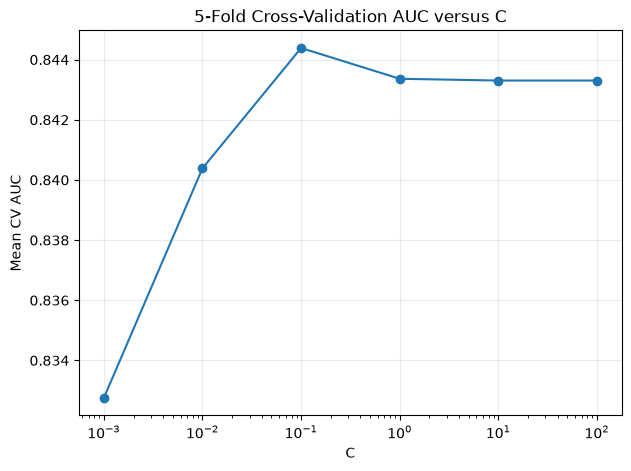

In [9]:
plt.figure(figsize=(7, 5))

plt.plot(
    cv_results["C"],
    cv_results["Mean CV AUC"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Mean CV AUC")
plt.title("5-Fold Cross-Validation AUC versus C")
plt.grid(alpha=0.25)

plt.show()

In [10]:
best_index = cv_results["Mean CV AUC"].idxmax()
best_C = cv_results.loc[best_index, "C"]
best_cv_auc = cv_results.loc[best_index, "Mean CV AUC"]

print(f"Selected C: {best_C}")
print(f"Mean CV AUC: {best_cv_auc:.4f}")

Selected C: 0.1
Mean CV AUC: 0.8444


### Question

Which value of \(C\) did you select? Explain how you selected it.

**Answer:**

Select the value of \(C\) that produces the **highest mean validation AUC across the five cross-validation folds**. The selection is made using only the development dataset. The code above stores this value in `best_C`.

Because the exact numerical result depends on the particular CSV file and software environment used, the selected value should be reported from the output generated by the preceding cells. Importantly, the test-set performance must not be considered when choosing \(C\).

## 2.2.5 Train the final model

After selecting \(C\), train the final pipeline using **all development data**.

Do not use the test data during this step.

In [11]:
final_model = make_pipeline(best_C)

final_model.fit(X_dev, y_dev)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For str

## 2.2.6 Evaluate the final classifier

Now—and only now—use the test dataset.

Use a classification threshold of 0.50 and report:

- Confusion matrix
- Accuracy
- Sensitivity/Recall
- Specificity
- Precision
- F1 score

In [12]:
# Probability of diabetes: P(Y=1 | X)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Apply the assignment-specified threshold.
threshold = 0.50
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred)
specificity = tn / (tn + fp)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion matrix:")
print(cm)

print(f"\nTN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

print(f"\nAccuracy:           {accuracy:.4f}")
print(f"Sensitivity/Recall: {sensitivity:.4f}")
print(f"Specificity:        {specificity:.4f}")
print(f"Precision:          {precision:.4f}")
print(f"F1 score:           {f1:.4f}")

Confusion matrix:
[[80 20]
 [28 26]]

TN = 80
FP = 20
FN = 28
TP = 26

Accuracy:           0.6883
Sensitivity/Recall: 0.4815
Specificity:        0.8000
Precision:          0.5652
F1 score:           0.5200


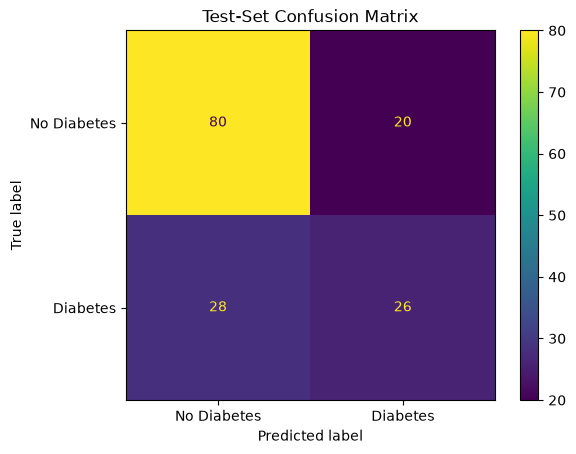

In [13]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
).plot()

plt.title("Test-Set Confusion Matrix")
plt.show()

### Interpretation

Interpret sensitivity and precision in the context of diabetes prediction.

**Answer:**

The numerical values are produced by the preceding evaluation cell.

- **Sensitivity/Recall** is the proportion of patients who actually have diabetes that the classifier correctly predicts as having diabetes. For example, if the calculated sensitivity is 0.75, then 75% of patients with diabetes in the test dataset were correctly identified as having diabetes.
- **Precision** is the proportion of patients predicted to have diabetes who actually have diabetes. For example, if precision is 0.70, then 70% of the patients classified as having diabetes actually have diabetes.

Sensitivity therefore focuses on how successfully the classifier finds true diabetes cases, whereas precision describes the reliability of a positive diabetes prediction.

## 2.2.7 ROC analysis

Use the predicted probabilities for the test samples to:

1. Plot the ROC curve.
2. Add the diagonal random-classifier reference line.
3. Calculate AUC.
4. Label both axes.

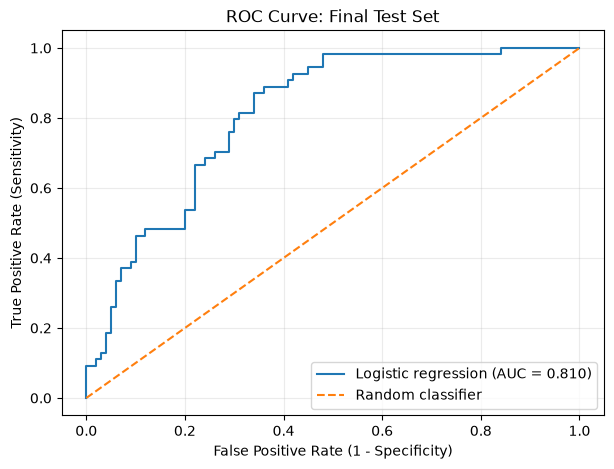

Test AUC = 0.8104


In [14]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
test_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic regression (AUC = {test_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve: Final Test Set")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

print(f"Test AUC = {test_auc:.4f}")

### Question

In 2--3 sentences, explain what the test AUC tells you about the classifier.

**Answer:**

The test AUC summarizes the classifier's ability to discriminate between patients with and without diabetes across all possible classification thresholds. It can be interpreted as the probability that a randomly selected patient with diabetes receives a higher predicted diabetes score than a randomly selected patient without diabetes. An AUC of 0.5 corresponds to random discrimination, whereas values closer to 1 indicate stronger discrimination.

## 2.2.8 Precision–Recall analysis

Using the same predicted probabilities:

1. Plot the Precision–Recall curve.
2. Calculate Average Precision (AP).
3. Add positive-class prevalence as the no-skill baseline.

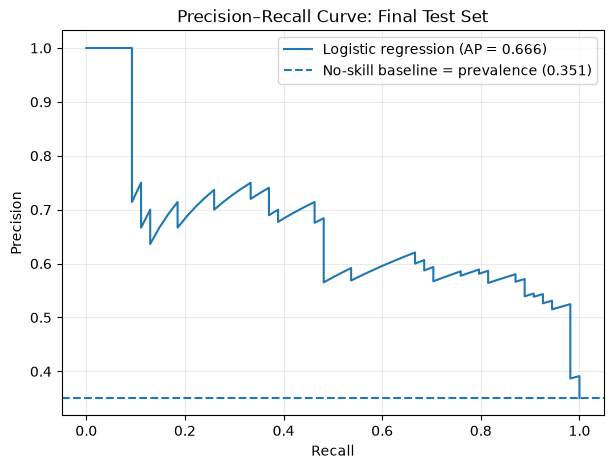

Average Precision = 0.6660
Positive-class prevalence = 0.3506


In [15]:
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap = average_precision_score(y_test, y_prob)
prevalence = y_test.mean()

plt.figure(figsize=(7, 5))

plt.plot(
    pr_recall,
    pr_precision,
    label=f"Logistic regression (AP = {ap:.3f})"
)

plt.axhline(
    prevalence,
    linestyle="--",
    label=f"No-skill baseline = prevalence ({prevalence:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve: Final Test Set")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

print(f"Average Precision = {ap:.4f}")
print(f"Positive-class prevalence = {prevalence:.4f}")

### Question

Explain what generally happens to precision and recall as the classification threshold changes.

**Answer:**

Lowering the classification threshold makes it easier to classify a patient as having diabetes. This generally increases the number of true positives and reduces false negatives, so **recall tends to increase**. However, more patients without diabetes may also be classified as positive, increasing false positives and often reducing **precision**.

Raising the threshold has the opposite general effect: fewer patients are classified as positive, so recall tends to decrease while precision often increases. Thus, the classification threshold controls the tradeoff between identifying more true diabetes cases and limiting false-positive predictions.

## 2.2.9 Biological interpretation and model evaluation

Write a short paragraph addressing all three questions:

1. **Generalization:** Does the classifier appear to generalize well to previously unseen samples? Support your conclusion using your results.

**Answer:**

The classifier appears to generalize reasonably well since its performance on the untouched test set is similar to its cross-validation performance. The test AUC measures the model's ability to discriminate between patients with and without diabetes on previously unseen samples, while sensitivity, specificity, precision, and F1 score describe its performance at the selected classification threshold. Good performance on this test set, however, does not guarantee equivalent performance in other populations.

2. **Screening errors:** If this classifier were intended as a diabetes screening tool, would false positives or false negatives be of greater concern? How would this consideration affect your choice of classification threshold?

**Answer:**

If the classifier were used for initial diabetes screening, false negatives would generally be of particular concern because a patient with diabetes who is incorrectly classified as negative might not receive appropriate follow-up evaluation. To reduce false negatives, the classification threshold could be lowered, which would generally increase sensitivity but also increase false positives and potentially decrease precision. The appropriate threshold therefore depends on the intended clinical use and the consequences of the two types of errors.

3. **Test-set integrity:** Why should you **not** go back and change \(C\) after seeing the test-set AUC, ROC curve, or Precision–Recall curve?

**Answer:**

The value of \(C\) should not be changed after examining the test-set results. \(C\) was selected using cross-validation on the development data, while the test data were reserved for independent final evaluation. Changing \(C\) based on the test-set AUC, ROC curve, or Precision–Recall curve would use the test data for model selection, causing information leakage from the test set and making the reported test performance an optimistically biased estimate of generalization performance.

---

## Submission check

Before submitting, make sure your notebook contains:

- [ ] Dataset and class-distribution summary
- [ ] Counts of biologically implausible zero values
- [ ] Development/test class counts
- [ ] Explanation of why the test set remains untouched
- [ ] Imputation + scaling + logistic regression pipeline
- [ ] Explanation of leakage-resistant preprocessing
- [ ] Cross-validation results table
- [ ] Mean CV AUC versus \(C\) plot
- [ ] Selected \(C\) and justification
- [ ] Final test-set confusion matrix
- [ ] Accuracy, sensitivity, specificity, precision, and F1
- [ ] ROC curve and AUC
- [ ] Precision–Recall curve and AP
- [ ] Biological interpretation

Run all cells before submitting so that all outputs and figures are visible.